# 04 — Implied Volatility & the Volatility Smile

Black-Scholes assumes **constant volatility** $\sigma$. But in the market, option prices imply different $\sigma$ values for different strikes — this contradicts the model's own assumption.

**Implied volatility (IV)** is the $\sigma$ that, when plugged into Black-Scholes, reproduces the observed market price:

$$\text{BS}(S, K, T, r,\, \sigma_{\text{imp}}) = C_{\text{market}}$$

Since there's no closed form to invert, we solve this numerically using **Newton-Raphson**:

$$\sigma_{n+1} = \sigma_n - \frac{\text{BS}(\sigma_n) - C_{\text{market}}}{\text{Vega}(\sigma_n)}$$

The derivative of BS price w.r.t. $\sigma$ is exactly Vega — which we already have.

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
from implied_vol import implied_volatility, volatility_smile
from black_scholes import call_price

## Newton-Raphson convergence
We verify the solver recovers the correct $\sigma$ from a synthetic market price.

In [2]:
S, K, T, r = 150.0, 150.0, 0.25, 0.05
true_sigma  = 0.30   # ground truth

synthetic_price = call_price(S, K, T, r, true_sigma)
recovered_sigma = implied_volatility(synthetic_price, S, K, T, r)

print(f"True sigma      : {true_sigma:.4f}")
print(f"Synthetic price : ${synthetic_price:.4f}")
print(f"Recovered sigma : {recovered_sigma:.4f}")
print(f"Error           : {abs(true_sigma - recovered_sigma):.2e}")

True sigma      : 0.3000
Synthetic price : $9.8746
Recovered sigma : 0.3000
Error           : 2.22e-16


## Fetching real option data
We load a live AAPL option chain and compute implied volatility for each strike.

In [3]:
import yfinance as yf
from datetime import datetime

ticker = yf.Ticker('AAPL')
S_real = ticker.history(period='1d')['Close'].iloc[-1]

# pick an expiry ~1-3 months out for good liquidity
expiry = ticker.options[2]
chain  = ticker.option_chain(expiry)
calls  = chain.calls.copy()

T_real = (datetime.strptime(expiry, '%Y-%m-%d') - datetime.today()).days / 365
r_real = 0.05

print(f"AAPL spot: ${S_real:.2f} | Expiry: {expiry} | T: {T_real:.3f} years")

# filter for liquid strikes: volume > 0 and near the money
calls = calls[calls['volume'] > 0].copy()
calls = calls[(calls['strike'] > S_real * 0.80) & (calls['strike'] < S_real * 1.20)]
calls = calls.reset_index(drop=True)

AAPL spot: $270.23 | Expiry: 2026-04-22 | T: 0.008 years


## Computing implied volatility per strike

In [4]:
calls['iv_computed'] = calls.apply(
    lambda row: implied_volatility(row['lastPrice'], S_real, row['strike'], T_real, r_real),
    axis=1
)

# drop strikes where solver didn't converge (too far ITM/OTM)
calls = calls.dropna(subset=['iv_computed'])

# moneyness: 1.0 = at the money
calls['moneyness'] = calls['strike'] / S_real

calls[['strike', 'lastPrice', 'iv_computed', 'impliedVolatility', 'moneyness']].head(10)

,strike,lastPrice,iv_computed,impliedVolatility,moneyness
7,255.0,15.50,0.379189,0.378180,0.943641
9,260.0,10.55,0.290366,0.297126,0.962143
10,262.5,8.40,0.308705,0.273567,0.971395
11,265.0,6.47,0.319886,0.231697,0.980646
12,267.5,4.32,0.273871,0.225105,0.989897
13,270.0,3.02,0.291411,0.212288,0.999149
14,272.5,1.80,0.279759,0.206307,1.008400
15,275.0,1.04,0.280728,0.201912,1.017652
16,280.0,0.34,0.298307,0.212654,1.036154
17,285.0,0.10,0.315070,0.238289,1.054657


## The Volatility Smile

If Black-Scholes were correct, implied volatility would be **flat** across all strikes — the same $\sigma$ would price all options consistently.

In practice it isn't. The resulting curve is called the **volatility smile** (or **skew** when asymmetric). It reflects:
- Higher demand for OTM puts as crash insurance → inflated IV on the downside
- Fat tails in real return distributions that GBM doesn't capture

This is one of Black-Scholes' most well-known failure modes.

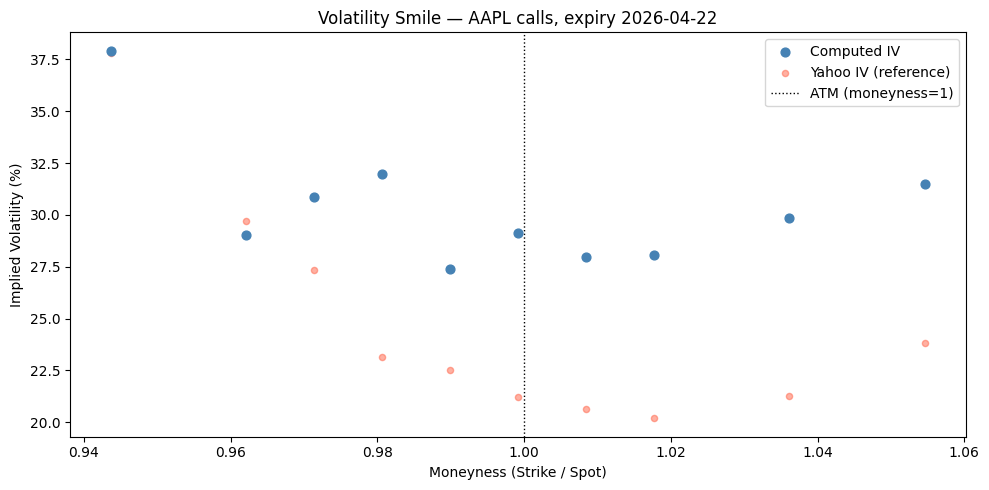

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(calls['moneyness'], calls['iv_computed'] * 100,
           label='Computed IV', color='steelblue', zorder=5, s=40)
ax.scatter(calls['moneyness'], calls['impliedVolatility'] * 100,
           label='Yahoo IV (reference)', color='tomato', alpha=0.5, s=20)

ax.axvline(1.0, color='black', linestyle=':', linewidth=1, label='ATM (moneyness=1)')
ax.set_xlabel('Moneyness (Strike / Spot)')
ax.set_ylabel('Implied Volatility (%)')
ax.set_title(f'Volatility Smile — AAPL calls, expiry {expiry}')
ax.legend()
plt.tight_layout()
plt.show()

## Volatility surface (across expiries)
The smile is not static — it changes with time to expiry. Plotting IV across both strikes and expiries gives the **volatility surface**, the real object that options desks manage.

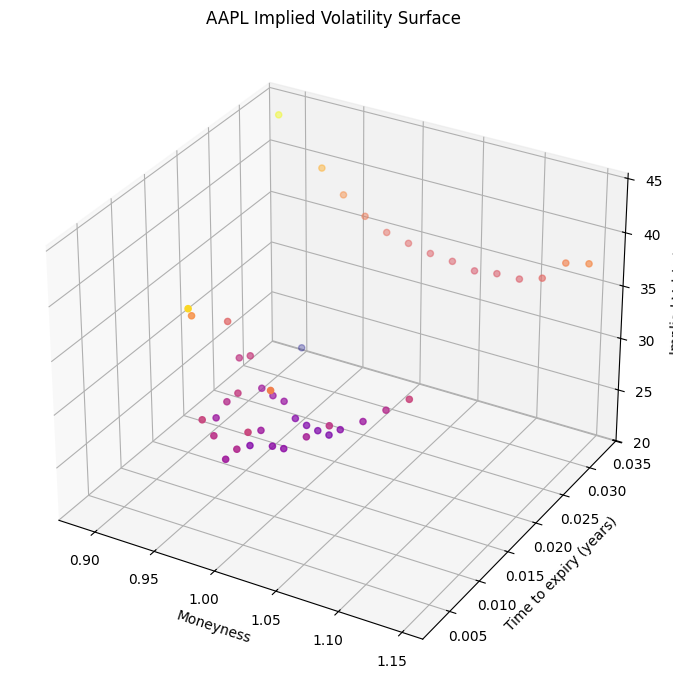

In [6]:
from mpl_toolkits.mplot3d import Axes3D

all_data = []

for exp in ticker.options[:5]:   # first 5 expiries
    T_exp = (datetime.strptime(exp, '%Y-%m-%d') - datetime.today()).days / 365
    if T_exp <= 0:
        continue
    ch = ticker.option_chain(exp).calls
    ch = ch[(ch['volume'] > 0) &
            (ch['strike'] > S_real * 0.85) &
            (ch['strike'] < S_real * 1.15)].copy()
    ch['T'] = T_exp
    ch['moneyness'] = ch['strike'] / S_real
    ch['iv'] = ch.apply(
        lambda row: implied_volatility(row['lastPrice'], S_real, row['strike'], T_exp, r_real),
        axis=1
    )
    all_data.append(ch[['moneyness', 'T', 'iv']].dropna())

import pandas as pd
surface_df = pd.concat(all_data, ignore_index=True)

fig = plt.figure(figsize=(11, 7))
ax  = fig.add_subplot(111, projection='3d')
ax.scatter(surface_df['moneyness'], surface_df['T'], surface_df['iv'] * 100,
           c=surface_df['iv'], cmap='plasma', s=20)
ax.set_xlabel('Moneyness')
ax.set_ylabel('Time to expiry (years)')
ax.set_zlabel('Implied Vol (%)')
ax.set_title('AAPL Implied Volatility Surface')
plt.tight_layout()
plt.show()